## Building models (many to many)

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [32]:
### loading the libraries
import pandas as pd
import numpy as np
import joblib

In [31]:
### importing the tensorflow libraries
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Bidirectional

In [3]:
### setting up the system path
import sys
sys.path.append('../')

In [4]:
### importing the libraries
from src.graphs.graphs_metrices import metrices, plot_predictions, plot_graphs_post_scaling
from src.future_pred.future_pred import gen_future_dates, gen_future_prices, gen_future_price_graphs
from src.build_sequences.build_sequences import build_sequences

In [22]:
### loading the data
df = pd.read_csv('../stocks/apple-18-2.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19 00:00:00+00:00,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22 00:00:00+00:00,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23 00:00:00+00:00,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24 00:00:00+00:00,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25 00:00:00+00:00,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [23]:
### changing the data type of the 'date'
df['date'] = df['date'].astype(dtype = 'date64[pyarrow]')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [24]:
### df_copy for the scaler comparison
df_copy = df.copy()
df_copy.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,129.87,130.7100,128.80,130.24,87668834,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,126.00,129.7200,125.60,128.01,102886922,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,125.86,126.7100,118.39,123.76,158273022,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,125.35,125.5600,122.23,124.94,111039904,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,120.99,126.4585,120.54,124.68,144766924,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


In [25]:
### features to target
features_to_target = ['close', 'high', 'low', 'open', 'volume']
features_to_target

['close', 'high', 'low', 'open', 'volume']

In [26]:
### scaling the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
df[features_to_target] = scaler.fit_transform(df[features_to_target])

feature : close


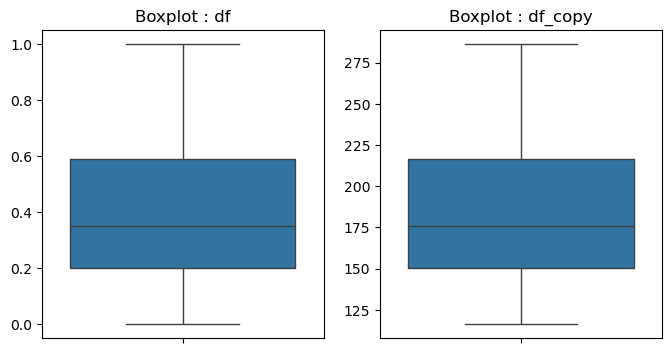

feature : high


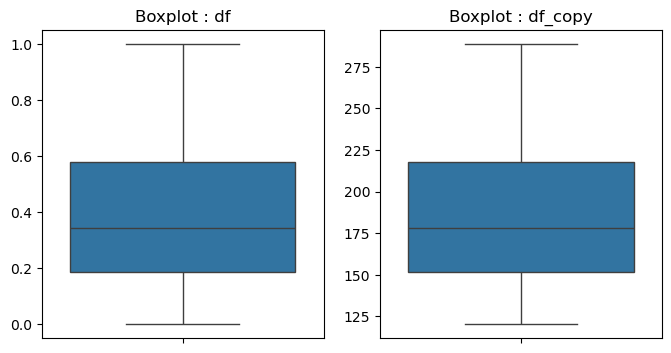

feature : low


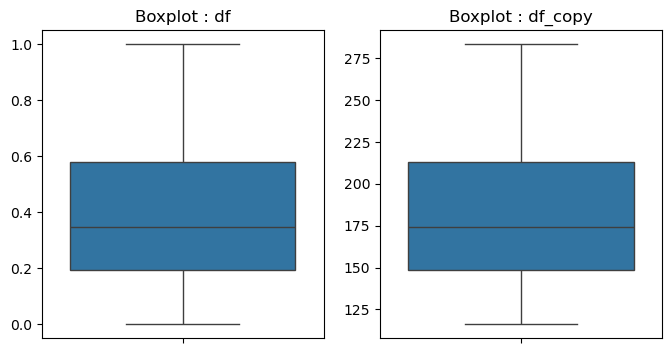

feature : open


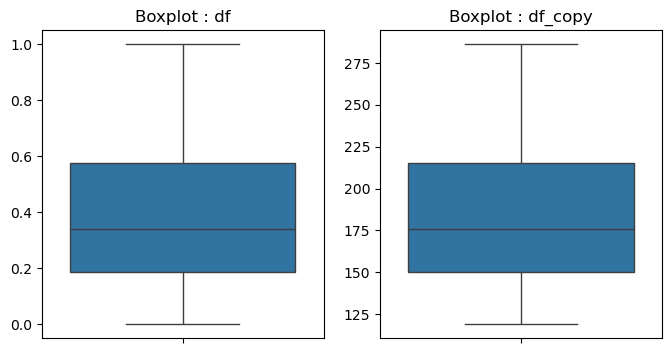

feature : volume


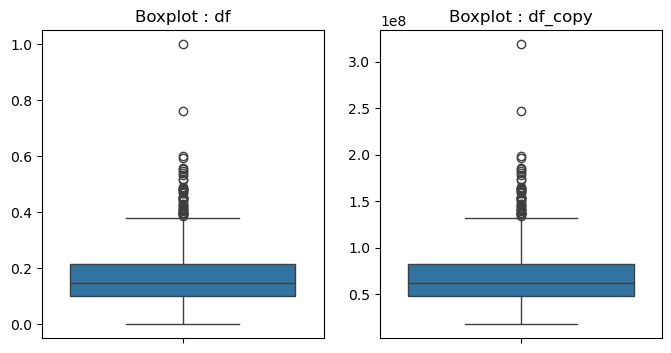

In [27]:
### plotting the scaled vs non scaled data
plot_graphs_post_scaling(df, df_copy, cols = features_to_target)

In [28]:
### saving the scaled data
df.to_csv('../stocks/apple_scaled.csv', index = False)

In [29]:
### loading again to check the data
df = pd.read_csv('../stocks/apple_scaled.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2021-02-19,0.079550,0.061271,0.075349,0.067057,0.231933,126.505301,127.323538,125.463023,126.865715,87668834,0.0,1.0
1,AAPL,2021-02-22,0.056763,0.055386,0.056197,0.053718,0.282530,122.735566,126.359187,122.345929,124.693491,102886922,0.0,1.0
2,AAPL,2021-02-23,0.055938,0.037493,0.013047,0.028295,0.466678,122.599193,123.427171,115.322727,120.553600,158273022,0.0,1.0
3,AAPL,2021-02-24,0.052935,0.030656,0.036028,0.035353,0.309637,122.102406,122.306966,119.063240,121.703029,111039904,0.0,1.0
4,AAPL,2021-02-25,0.027263,0.035998,0.025914,0.033798,0.421773,117.855366,123.182187,117.417025,121.449765,144766924,0.0,1.0


### 90 days window

In [11]:
### making the sequences
X_train_90, X_test_90, y_train_90, y_test_90 = build_sequences(df, days = 90, features_to_target = features_to_target)

(1004, 90, 5) :: (1004, 5) 
(161, 90, 5) :: (161, 5)


In [33]:
### making the sequence model
model_90 = Sequential([
    LSTM(50, return_sequences = True, input_shape = (9, 5)),
    Dropout(0.33),
    Bidirectional(LSTM(100)),
    Dropout(0.33),
    Dense(5, activation = 'linear')
])
model_90.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mse'])

c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
### checking the model summary
model_90.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 9, 50)          │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,005 (519.55 KB)

 Trainable params: 133,005 (519.55 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
### training the model
model_90.fit(X_train_90, y_train_90, batch_size = 32, epochs = 30, verbose = 1)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0359 - mse: 0.0359
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0076 - mse: 0.0076
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0060 - mse: 0.0060
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0052 - mse: 0.0052
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0044 - mse: 0.0044
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0048 - mse: 0.0048
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0044 - mse: 0.0044
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0044 - mse: 0.0044
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0042 - mse: 0.0042
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0041 - mse: 0.0041
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0039 - mse: 0.0039
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0037 - mse: 0.0037
Epoch 13/30
32/32 ━━━━━━━━━━━━━━━━━━━

In [36]:
### y_pred_90
y_pred_90 = model_90.predict(X_test_90)
y_pred_90

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step


array([[0.5163034 , 0.51101905, 0.5082407 , 0.5049975 , 0.13041537],
       [0.5163867 , 0.51070535, 0.50773525, 0.50513506, 0.14006439],
       [0.52250326, 0.51678157, 0.5133781 , 0.5117978 , 0.14792953],
       [0.53429306, 0.5287751 , 0.5252363 , 0.52437246, 0.14958818],
       [0.5522167 , 0.54736817, 0.5438626 , 0.5430031 , 0.14179097],
       [0.56576824, 0.5614206 , 0.55799866, 0.5565187 , 0.13492364],
       [0.57414895, 0.5700358 , 0.56676996, 0.56433237, 0.12912247],
       [0.5771886 , 0.5728899 , 0.56979233, 0.5667254 , 0.12659426],
       [0.57890683, 0.57478094, 0.5722342 , 0.56830144, 0.12262052],
       [0.57950294, 0.5754075 , 0.573184  , 0.56876516, 0.11973215],
       [0.5773628 , 0.57303506, 0.57134014, 0.56634605, 0.1167596 ],
       [0.57437545, 0.5698541 , 0.5686319 , 0.5632267 , 0.11580231],
       [0.57099575, 0.566052  , 0.5652627 , 0.5599295 , 0.11709659],
       [0.5675188 , 0.5624642 , 0.5619271 , 0.55684996, 0.11953183],
       [0.56573755, 0.5608868 , 0.

In [37]:
### checking the y_pred_90 shape
y_pred_90.shape

(161, 5)

In [38]:
### using the inverse scaler
y_test_90 = scaler.inverse_transform(y_test_90)
y_pred_90 = scaler.inverse_transform(y_pred_90)

feature : close
MAE : 4.828240773455699
MSE : 40.99381041504789
RMSE : 6.402640893806859


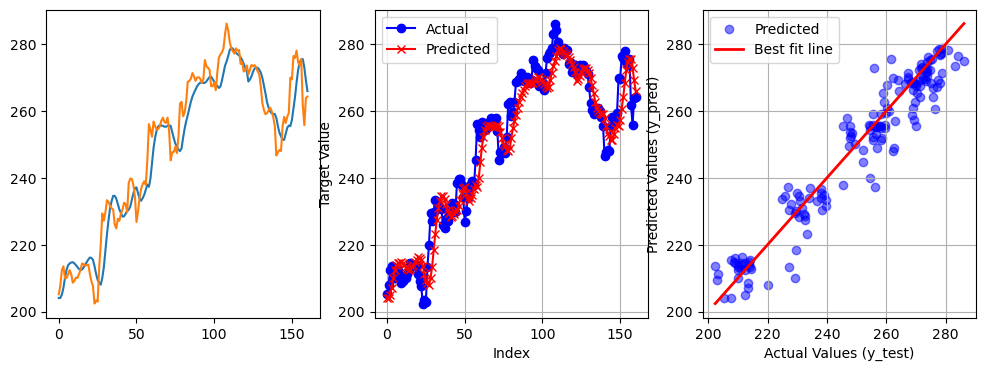

feature : high
MAE : 4.458441370614566
MSE : 33.65631041130877
RMSE : 5.8014058995478655


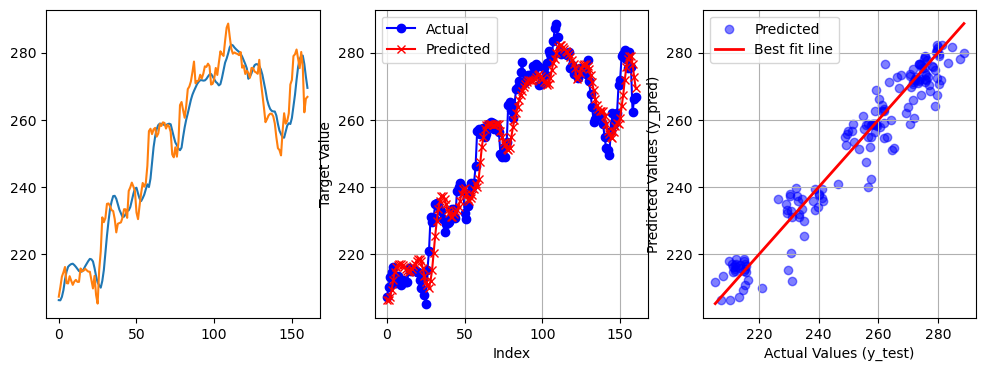

feature : low
MAE : 4.739941575025477
MSE : 37.41779579555991
RMSE : 6.117008729400336


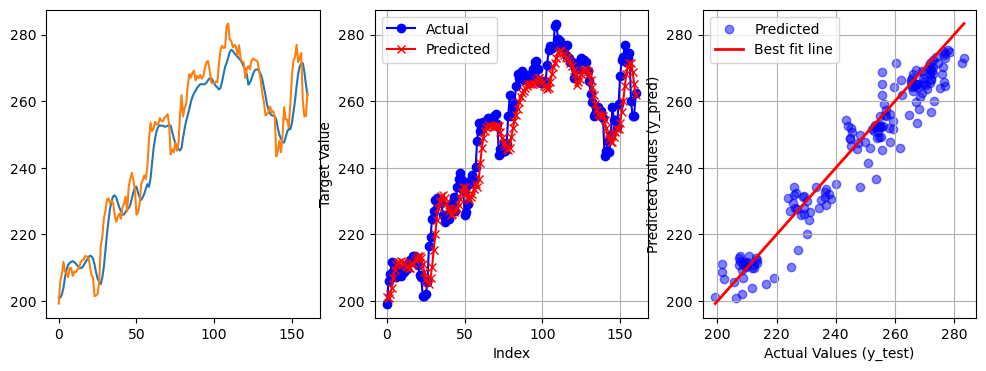

feature : open
MAE : 3.9172768274153236
MSE : 27.299541815553493
RMSE : 5.224896344957811


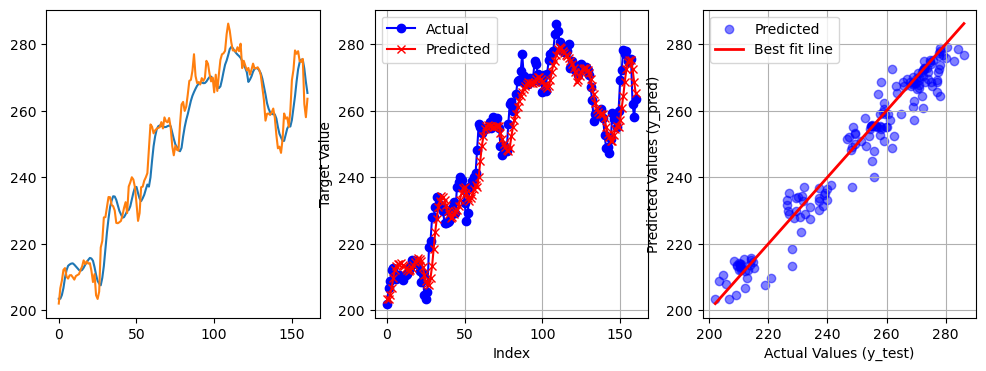

feature : volume
MAE : 13492512.51552795
MSE : 394505070290619.75
RMSE : 19862151.703443907


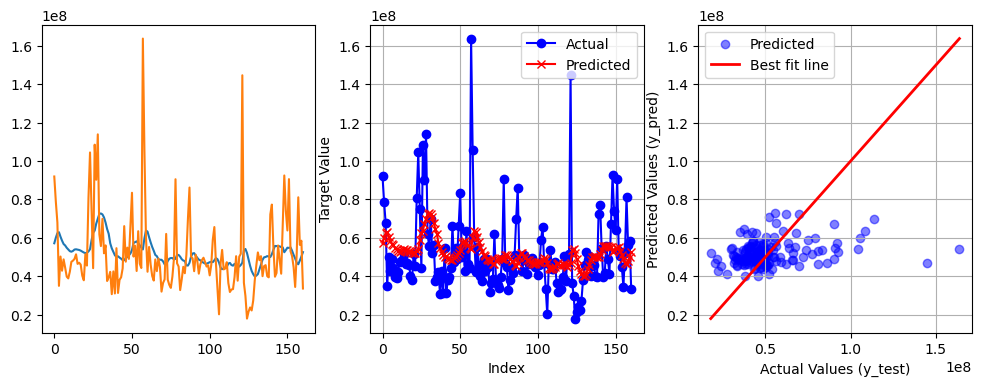

In [53]:
### metrices and graphs
for i in range (0, 5) : 
    print(f"feature : {features_to_target[i]}")
    metrices(y_test_90[:, i], y_pred_90[:, i])
    plot_predictions(y_test_90[:, i], y_pred_90[:, i])